In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving ETH_RTFP_mkt_2007_2026-08-03.csv to ETH_RTFP_mkt_2007_2026-08-03 (1).csv


In [ ]:
wb = pd.read_csv('ETH_RTFP_mkt_2007_2026-08-03.csv')
print(wb.shape)
print(wb.columns.tolist())
wb.head()


(30444, 74)
['ISO3', 'country', 'adm1_name', 'adm2_name', 'mkt_name', 'lat', 'lon', 'geo_id', 'price_date', 'year', 'month', 'currency', 'components', 'start_dense_data', 'last_survey_point', 'data_coverage', 'data_coverage_recent', 'index_confidence_score', 'spatially_interpolated', 'livestock_goat', 'livestock_sheep', 'maize', 'pasta', 'sorghum', 'teff_fao', 'wheat', 'o_livestock_goat', 'h_livestock_goat', 'l_livestock_goat', 'c_livestock_goat', 'inflation_livestock_goat', 'trust_livestock_goat', 'o_livestock_sheep', 'h_livestock_sheep', 'l_livestock_sheep', 'c_livestock_sheep', 'inflation_livestock_sheep', 'trust_livestock_sheep', 'o_maize', 'h_maize', 'l_maize', 'c_maize', 'inflation_maize', 'trust_maize', 'o_pasta', 'h_pasta', 'l_pasta', 'c_pasta', 'inflation_pasta', 'trust_pasta', 'o_sorghum', 'h_sorghum', 'l_sorghum', 'c_sorghum', 'inflation_sorghum', 'trust_sorghum', 'o_teff_fao', 'h_teff_fao', 'l_teff_fao', 'c_teff_fao', 'inflation_teff_fao', 'trust_teff_fao', 'o_wheat', 'h_wh

,ISO3,country,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,price_date,year,...,l_wheat,c_wheat,inflation_wheat,trust_wheat,o_food_price_index,h_food_price_index,l_food_price_index,c_food_price_index,inflation_food_price_index,trust_food_price_index
0,ETH,Ethiopia,Afar,ZONE2,Abaala,13.36,39.76,gid_133600000397600000,2007-01-01,2007,...,3.30,3.77,NaN,9.3,0.19,0.21,0.18,0.20,NaN,9.8
1,ETH,Ethiopia,Afar,ZONE2,Abaala,13.36,39.76,gid_133600000397600000,2007-02-01,2007,...,3.40,3.69,NaN,9.3,0.20,0.23,0.19,0.23,NaN,9.8
2,ETH,Ethiopia,Afar,ZONE2,Abaala,13.36,39.76,gid_133600000397600000,2007-03-01,2007,...,3.31,4.09,NaN,9.3,0.23,0.25,0.18,0.18,NaN,9.8
3,ETH,Ethiopia,Afar,ZONE2,Abaala,13.36,39.76,gid_133600000397600000,2007-04-01,2007,...,3.76,3.89,NaN,9.3,0.19,0.23,0.17,0.23,NaN,9.8
4,ETH,Ethiopia,Afar,ZONE2,Abaala,13.36,39.76,gid_133600000397600000,2007-05-01,2007,...,3.55,4.16,NaN,9.3,0.23,0.26,0.20,0.21,NaN,9.8


In [ ]:
import pandas as pd

wb = pd.read_csv('ETH_RTFP_mkt_2007_2026-08-03.csv')
print(wb.shape)
print(wb.columns.tolist())
print(wb.head().to_string())

(30444, 74)
['ISO3', 'country', 'adm1_name', 'adm2_name', 'mkt_name', 'lat', 'lon', 'geo_id', 'price_date', 'year', 'month', 'currency', 'components', 'start_dense_data', 'last_survey_point', 'data_coverage', 'data_coverage_recent', 'index_confidence_score', 'spatially_interpolated', 'livestock_goat', 'livestock_sheep', 'maize', 'pasta', 'sorghum', 'teff_fao', 'wheat', 'o_livestock_goat', 'h_livestock_goat', 'l_livestock_goat', 'c_livestock_goat', 'inflation_livestock_goat', 'trust_livestock_goat', 'o_livestock_sheep', 'h_livestock_sheep', 'l_livestock_sheep', 'c_livestock_sheep', 'inflation_livestock_sheep', 'trust_livestock_sheep', 'o_maize', 'h_maize', 'l_maize', 'c_maize', 'inflation_maize', 'trust_maize', 'o_pasta', 'h_pasta', 'l_pasta', 'c_pasta', 'inflation_pasta', 'trust_pasta', 'o_sorghum', 'h_sorghum', 'l_sorghum', 'c_sorghum', 'inflation_sorghum', 'trust_sorghum', 'o_teff_fao', 'h_teff_fao', 'l_teff_fao', 'c_teff_fao', 'inflation_teff_fao', 'trust_teff_fao', 'o_wheat', 'h_wh

In [ ]:
import pandas as pd

wb = pd.read_csv('ETH_RTFP_mkt_2007_2026-08-03.csv')

commodities = ['livestock_goat', 'livestock_sheep', 'maize', 'pasta', 'sorghum', 'teff_fao', 'wheat']

id_cols = ['country', 'adm1_name', 'adm2_name', 'mkt_name', 'lat', 'lon', 'price_date', 'year', 'month', 'currency']

records = []
for commodity in commodities:
    cols_needed = {
        'open': f'o_{commodity}', 'high': f'h_{commodity}',
        'low': f'l_{commodity}', 'close': f'c_{commodity}',
        'inflation': f'inflation_{commodity}', 'trust': f'trust_{commodity}'
    }
    subset = wb[id_cols + list(cols_needed.values())].copy()
    subset = subset.rename(columns={v: k for k, v in cols_needed.items()})
    subset['commodity'] = commodity
    records.append(subset)

long_df = pd.concat(records, ignore_index=True)


long_df = long_df.dropna(subset=['close'])

print(long_df.shape)
print(long_df.head(10))

long_df.to_csv('ethiopia_prices_clean.csv', index=False)

(213108, 17)
    country adm1_name adm2_name mkt_name    lat    lon  price_date  year  \
0  Ethiopia      Afar     ZONE2   Abaala  13.36  39.76  2007-01-01  2007   
1  Ethiopia      Afar     ZONE2   Abaala  13.36  39.76  2007-02-01  2007   
2  Ethiopia      Afar     ZONE2   Abaala  13.36  39.76  2007-03-01  2007   
3  Ethiopia      Afar     ZONE2   Abaala  13.36  39.76  2007-04-01  2007   
4  Ethiopia      Afar     ZONE2   Abaala  13.36  39.76  2007-05-01  2007   
5  Ethiopia      Afar     ZONE2   Abaala  13.36  39.76  2007-06-01  2007   
6  Ethiopia      Afar     ZONE2   Abaala  13.36  39.76  2007-07-01  2007   
7  Ethiopia      Afar     ZONE2   Abaala  13.36  39.76  2007-08-01  2007   
8  Ethiopia      Afar     ZONE2   Abaala  13.36  39.76  2007-09-01  2007   
9  Ethiopia      Afar     ZONE2   Abaala  13.36  39.76  2007-10-01  2007   

   month currency    open    high     low   close  inflation  trust  \
0      1      ETB  213.77  232.90  202.88  217.92        NaN    9.8   
1      2

In [ ]:
print(long_df['inflation'].notna().sum(), "of", len(long_df), "rows have inflation data")

202272 of 213108 rows have inflation data


In [ ]:
# Check for duplicates
print(long_df.duplicated().sum())

# Check value ranges per commodity (catch bad data)
long_df.groupby('commodity')['close'].describe()

# Check date range coverage
print(long_df['price_date'].min(), long_df['price_date'].max())

# Missing trust scores or extreme low-trust rows worth flagging
print((long_df['trust'] < 5).sum(), "low-trust rows")

0
2007-01-01 2026-08-01
0 low-trust rows


we verified no duplicate records and no low-confidence estimates in the dataset


In [ ]:
import numpy as np

teff = long_df[long_df['commodity'] == 'teff_fao']['close'].dropna()
print("Mean:", np.mean(teff))
print("Std dev:", np.std(teff))
print("Median:", np.median(teff))

Mean: 3151.689261266588
Std dev: 3236.0633069717605
Median: 1526.665


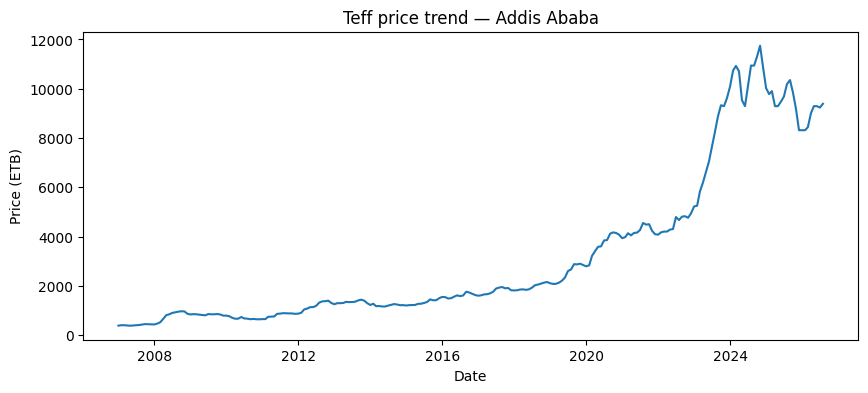

In [ ]:
import matplotlib.pyplot as plt

teff_addis = long_df[(long_df['commodity']=='teff_fao') & (long_df['mkt_name']=='Addis Ababa')].sort_values('price_date')
plt.figure(figsize=(10,4))
plt.plot(pd.to_datetime(teff_addis['price_date']), teff_addis['close'])
plt.title('Teff price trend — Addis Ababa')
plt.xlabel('Date'); plt.ylabel('Price (ETB)')
plt.show()

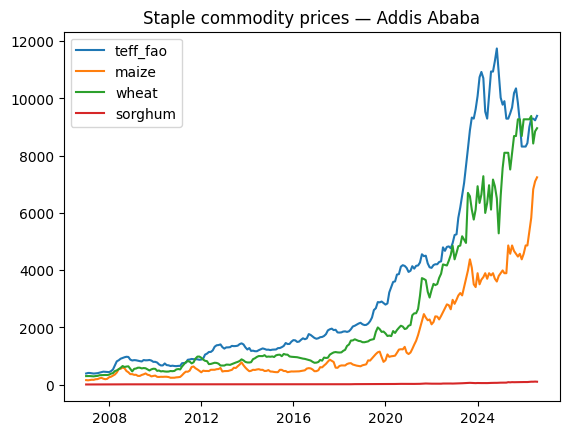

In [ ]:
for commodity in ['teff_fao', 'maize', 'wheat', 'sorghum']:
    subset = long_df[(long_df['commodity']==commodity) & (long_df['mkt_name']=='Addis Ababa')].sort_values('price_date')
    plt.plot(pd.to_datetime(subset['price_date']), subset['close'], label=commodity)
plt.legend(); plt.title('Staple commodity prices — Addis Ababa')
plt.show()

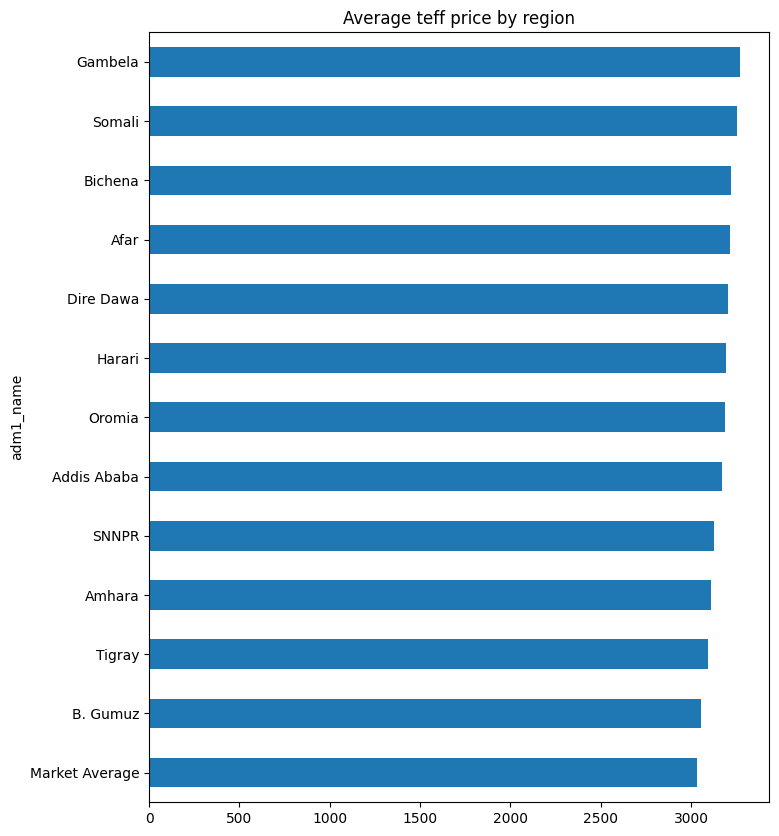

In [ ]:
region_avg = long_df[long_df['commodity']=='teff_fao'].groupby('adm1_name')['close'].mean().sort_values()
region_avg.plot(kind='barh', figsize=(8,10))
plt.title('Average teff price by region')
plt.show()

In [ ]:
volatility = long_df.groupby('commodity')['close'].std().sort_values(ascending=False)
print(volatility)

commodity
teff_fao           3236.116456
wheat              2931.293569
livestock_goat     2600.700086
livestock_sheep    2528.870816
maize              1758.068209
pasta                53.443499
sorghum              24.282361
Name: close, dtype: float64


In [ ]:
# Much more meaningful: yearly average
long_df['year'] = long_df['year'].astype(int)
teff_by_year = long_df[long_df['commodity']=='teff_fao'].groupby('year')['close'].mean()
print(teff_by_year)

year
2007      404.775265
2008      787.681253
2009      819.556596
2010      679.507313
2011      806.756712
2012     1155.601938
2013     1272.476602
2014     1211.377196
2015     1290.141809
2016     1466.103398
2017     1679.064864
2018     1914.737584
2019     2274.023902
2020     3134.174871
2021     4040.218986
2022     4775.848708
2023     7481.737642
2024     9851.271266
2025     9889.684063
2026    10572.723256
Name: close, dtype: float64


In [ ]:
cv = long_df.groupby('commodity')['close'].agg(['mean', 'std'])
cv['coefficient_of_variation'] = cv['std'] / cv['mean']
print(cv.sort_values('coefficient_of_variation', ascending=False))

                        mean          std  coefficient_of_variation
commodity                                                          
wheat            1866.987855  2931.293569                  1.570066
livestock_sheep  2169.859197  2528.870816                  1.165454
sorghum            20.994865    24.282361                  1.156586
livestock_goat   2322.719043  2600.700086                  1.119679
maize            1571.106117  1758.068209                  1.119000
teff_fao         3151.689261  3236.116456                  1.026788
pasta              55.501482    53.443499                  0.962920


In [ ]:
long_df.to_csv('ethiopia_prices_clean.csv', index=False)

from google.colab import files
files.download('ethiopia_prices_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>